In [ ]:
# --- LPA repo path bootstrap (added during repository reorganization) ---
# Makes this notebook find the project source (src/) and the data folders at the
# repository root, no matter which notebooks/<topic>/ subfolder it lives in.
# Run this cell first.
import os, sys

_root = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_root, "pyproject.toml")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root)                       # so relative data paths (e.g. "Dataset/...") resolve
_src = os.path.join(_root, "src")
if _src not in sys.path:
    sys.path.insert(0, _src)          # so `from LPA import ...` works without installing
print("working dir set to repo root:", _root)


In [1]:
!pip install -r requirements.txt --user

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

You should consider upgrading via the 'python -m pip install --upgrade pip' command.


## Imports

In [1]:
import pandas as pd
from LPA import Corpus, sockpuppet_distance , PCA
import altair as alt
alt.data_transformers.disable_max_rows()
import os
from typing import List
from visualize import plot_pca
import re
from collections import Counter
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import zipfile
from bs4 import BeautifulSoup
import shutil
import html2text
import re
import ast
import scipy.stats as stats
from sklearn.metrics import f1_score, precision_score, recall_score
import random


# Global Variables 

In [2]:
data_folders = ["Harry_Potter" , "lord_of_the_rings", "pok_mon" , "twilight" , "Warcraft"]

Set up Data

In [3]:
def copy_english_files(input_path, output_path):
    num_copied = 0
    
    # create output folder if it doesn't exist
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    
    # loop through csv files in input folder
    for filename in os.listdir(input_path):
        if filename.endswith('.csv'):
            # read csv file into a pandas DataFrame
            df = pd.read_csv(os.path.join(input_path, filename))
            
            # check if "English" appears in the "Language" column
            if "English" in df["Language"].values:
                # copy file to output folder
                shutil.copy(os.path.join(input_path, filename), os.path.join(output_path, filename))
                num_copied += 1
    
    return num_copied

In [13]:
data_path = "Dataset/Data/"


for f in data_folders:
    os.makedirs(data_path+f+"/FanFictionCSVEnglish" , exist_ok=True)
    num_files = copy_english_files(data_path+f+"/FanFictionCSV" , data_path+f+"/FanFictionCSVEnglish")
    print(f"Copied {num_files} files from {f}")

Copied 38003 files from Harry_Potter
Copied 2838 files from lord_of_the_rings
Copied 10891 files from pok_mon
Copied 8384 files from twilight
Copied 586 files from Warcraft


In [40]:
for f in data_folders:
    data_current_path = data_path+f
    os.makedirs(data_current_path+"/FanFictionNormalSizesCSV" , exist_ok=True)
    os.makedirs(data_current_path+"/Divided_by_authors" , exist_ok=True)
    os.makedirs(data_current_path+"/authors_with_2Stories_OrLess" , exist_ok=True)
    os.makedirs(data_current_path+"/2Stories_OrLess_Undivided" , exist_ok=True)
    move_only_normal_sizes_normalize(data_current_path+"/FanFictionCSVEnglish",
                       data_current_path+"/FanFictionNormalSizesCSV" , min_length=400)
    copy_csv_to_folders(data_current_path+"/FanFictionNormalSizesCSV" ,data_path+f+"/Divided_by_authors")
    
    copy_folders_with_up_to_files(data_current_path+"/Divided_by_authors",
                                 data_current_path+"/authors_with_2Stories_OrLess")
    copy_all_files(data_current_path+"/authors_with_2Stories_OrLess", data_current_path+"/2Stories_OrLess_Undivided")


In [19]:
data_path = "Dataset/Data/"
for f in data_folders:
    data_current_path = data_path+f
    word_freq_full_folder(folder_path = data_current_path+"/2Stories_OrLess_Undivided")

## Functions

In [4]:
def read_array_of_dicts_file(file_path):
    with open(file_path, "r") as file:
        # Read the file contents as a string
        file_contents = file.read().rstrip()
        # Convert the string to a Python object (list of dictionaries)
        array_of_dicts = ast.literal_eval(file_contents)
    return array_of_dicts

In [6]:
# write each dictionary as a row in the CSV file
def prompts_to_csv(my_list_of_dicts , out_path):
    for my_dict in my_list_of_dicts:
        if len(my_dict["prompt"]) > 90:
            my_dict["prompt"] =   my_dict["prompt"][:90]+".csv"
        with open(out_path+my_dict["prompt"]+".csv", "w", newline="", encoding="utf8") as output_file:
                # write the story info to a csv file
                writer = csv.DictWriter(output_file, fieldnames=["id", "prompt", "FullStory"])
                writer.writeheader()
                writer.writerow(my_dict)


In [7]:
def run_LPA_Undivided(experimentpath):
    res_folder = experimentpath+"/Results/FanFiction"
    author_name = folder_path.rsplit(type1, 1)[-1]
    if not os.path.exists(res_folder):
        os.makedirs(res_folder)
    # Run LPA and DVR    
    freq = read_csv_folder(folder_path + "/word_freq")
    freq.rename(columns={'origin_index': 'document', 'word': 'element' , 'frequency': 'frequency_in_document'}, inplace=True)
    corpus = Corpus(freq=freq)
    dvr = corpus.create_dvr()
    #Export to csv
    dvr.to_csv(experimentpath +"/"+author_name+"-dvr.csv",mode='w',header=True, index=True)
    epsilon_frac = 2
    epsilon = 1 / (len(dvr) * epsilon_frac)
    epsilon
    signatures = corpus.create_signatures(epsilon=epsilon, sig_length=100, distance="KLDe")
    ## Export signitures
    if not os.path.exists(experimentpath + "/Signatures"):
        os.makedirs(experimentpath + "/Signatures/")
    write_dataframes_to_csv(signatures , outputFolder = res_folder + "/Signatures/" )
    
    

In [8]:
def run_LPA_for_each_author(experimentpath):
    nonprompts = experimentpath+"/Data/authors_with_2Stories_OrLess"
    for folder_name in os.listdir(nonprompts):
        folder_path = os.path.join(nonprompts, folder_name)
        LPA_Wrapper_Author(folder_path , experimentpath)

In [9]:
def LPA_Wrapper_Author(folder_path , experimentpath):
    # Set Up The Folder
    res_folder = folder_path + "/LPA_Results"
    author_name = folder_path.rsplit(type1, 1)[-1]
    res_folder = experimentpath+"/Results/Author_Results/"+author_name
    if not os.path.exists(res_folder):
        os.makedirs(res_folder)
    # Run LPA and DVR    
    freq = read_csv_folder(folder_path + "/word_freq")
    freq.rename(columns={'origin_index': 'document', 'word': 'element' , 'frequency': 'frequency_in_document'}, inplace=True)
    corpus = Corpus(freq=freq)
    dvr = corpus.create_dvr()
    #Export to csv
    dvr.to_csv(res_folder +"/"+author_name+"-dvr.csv",mode='w',header=True, index=True)
    epsilon_frac = 2
    epsilon = 1 / (len(dvr) * epsilon_frac)
    epsilon
    signatures = corpus.create_signatures(epsilon=epsilon, sig_length=100, distance="KLDe")
    ## Export signitures
    if not os.path.exists(experimentpath + "/Signatures/Author_Results/"+author_name):
        os.makedirs(experimentpath + "/Signatures/Author_Results/"+author_name)
    write_dataframes_to_csv(signatures , outputFolder = experimentpath + "/Signatures/Author_Results/"+author_name )

In [10]:
def wordfreqAll(experimentpath):
    nonprompts = experimentpath+"/Data/authors_with_2Stories_OrLess"
    nonprompts_undivided = experimentpath+"/Data/2Stories_OrLess_Undivided"
    for folder_name in os.listdir(nonprompts):
        folder_path = os.path.join(nonprompts, folder_name)
        word_freq_full_folder(folder_path)
    word_freq_full_folder(folder_path = nonprompts_undivided)


In [11]:
def preprocess_Data(experimentpath , min_length , max_length):
    txt_to_csv(folder_path=experimentpath+"/Data/FanFictionTXT" , out_path = experimentpath+"/Data/FanFictionCSV")
    move_only_normal_sizes(experimentpath+"/Data/FanFictionCSV",
                           experimentpath+"/Data/FanFictionNormalSizesCSV" , min_length=min_length-50 , max_length = max_length+50)
    copy_csv_to_folders(experimentpath+"/Data/FanFictionNormalSizesCSV" ,experimentpath+"/Data/Divided_by_authors")
    copy_folders_with_up_to_files(experimentpath+"/Data/Divided_by_authors",
                                     experimentpath+"/Data/authors_with_2Stories_OrLess")
    copy_all_files(experimentpath+"/Data/authors_with_2Stories_OrLess", experimentpath+"/Data/2Stories_OrLess_Undivided")

In [12]:
def unzipfromDataset(key_word , experimentpath, dataset_folder = "Dataset/" ):
    for file_name in os.listdir(dataset_folder):
        if file_name.endswith(".zip"):
            unzipFile(os.path.join(dataset_folder, file_name) , key_word , experimentpath+"/Data/FanFictionTXT")
            

## Directory Functions

In [13]:
def unzipFile(zip_path , keyword , dest):
    # create a directory for the harry potter files
#     os.makedirs(keyword, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zip_file:
    # loop over all files in the zip file
        for member in zip_file.namelist():
            filename = os.path.basename(member)
            # skip directories
            if not filename:
                continue
            # check if the file name contains "harry potter" (case-insensitive)
            if keyword in member.lower():
                source = zip_file.open(member)
                target = open(os.path.join(dest, filename), "wb")
                with source, target:
                    shutil.copyfileobj(source, target)
                # extract the file to the harry potter directory
#                 zip_file.extract(file_name, dest)
                
def remove_extra_white_space(source):
    """
    removes extra white spaces (more than 1 in a row).
    @param source:The original text
    @type source:str
    @return:A string without extra whitespaces
    @rtype:str
    """
    return re.sub(' +', ' ', source).strip()


def clean_with_html2text(handler, raw_html):
    """
    Use HTML2Text to clean data
    @param handler: preference of the way of cleaning
    @type handler:HTML2Text
    @param raw_html:A string of html code
    @type raw_html:str
    @return:clean document
    @rtype:str
    """
    return handler.handle(raw_html)


def create_handler(ignore_links=True, ignore_images=True, ignore_emphasis=True, skip_internal_links=True,
                   ignore_anchors=False):
    """
    Create a Handler for HTML2Text
    @param ignore_links:
    @type ignore_links:
    @param ignore_images:
    @type ignore_images:
    @param ignore_emphasis:
    @type ignore_emphasis:
    @param skip_internal_links:
    @type skip_internal_links:
    @param ignore_anchors:
    @type ignore_anchors:
    @return:
    @rtype:
    """
    handler = html2text.HTML2Text()
    handler.ignore_links = ignore_links
    handler.ignore_images = ignore_images
    handler.ignore_emphasis = ignore_emphasis
    handler.skip_internal_links = skip_internal_links
    handler.ignore_anchors = ignore_anchors
    return handler

def clean_html_beautiful_soup(raw_html):
    """
    Clean HTML using BeautifulSoup # returns String
    @param raw_html:
    @type raw_html:
    @return:only displayed text from html code
    @rtype:str
    """
    gfg = BeautifulSoup(raw_html)
    res = gfg.get_text()
    return res                


def txt_to_csv(folder_path="harry potter\H" , out_path = "harry potter\csv"):
    meta_keys = ["Category:", "Genre:", "Language:", "Status:", "Published:", "Updated:", "Packaged:", "Rating:", "Chapters:", 
                 "Words:","Publisher:", "Story URL:", "Author URL:", "Summary:"]
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".txt"):
            # set the input and output file paths
            input_file_path = os.path.join(folder_path, file_name)
            output_file_path = os.path.join(out_path, file_name.replace(".txt", ".csv"))

            # open the input and output files
            with open(input_file_path, "r" , encoding="utf8") as input_file , open(output_file_path, "w", newline="", encoding="utf8") as output_file:
                story_info = {}
                fullstory = ""
                for idx , line in enumerate(input_file.readlines()):
                    if  line.strip() == "End file.":
                        continue
                    if line.strip():
#                         print (idx , line)
                        if any (s in line for s in meta_keys):
                            key, value = line.split(":", 1)
                            if key not  in story_info:
                                story_info[key.strip()] = value.strip()
                        else:
                            fullstory = fullstory + " "+ line
                
                story_info["FullStory"] =  clean_html_beautiful_soup(remove_extra_white_space(fullstory))
                # write the story info to a csv file
                writer = csv.DictWriter(output_file, fieldnames=story_info.keys())
                writer.writeheader()
                writer.writerow(story_info)
                

def move_only_normal_sizes(input_folder, output_folder , max_length=600 , min_length=100 , field ="FullStory"):
    for file_name in os.listdir(input_folder):
        if file_name.endswith(".csv"):
            input_file_path = os.path.join(input_folder, file_name)
            output_file_path = os.path.join(output_folder, file_name)
            df = pd.read_csv(input_file_path , low_memory = False)
            if len(df.loc[0, field].split()) >= min_length and  len(df.loc[0, field].split()) <= max_length:
                df[field] = df[field].str.rstrip('End file.').str.strip() 
                df.to_csv(output_file_path,mode='w',header=True, index=True)

                
def copy_folders_with_multiple_files(source_folder, dest_folder , min_num_of_files= 2):
    """
    Copies subfolders from a source folder to a destination folder only if the subfolder
    contains more than one file.
    
    Args:
    - source_folder (str): Path to the source folder.
    - dest_folder (str): Path to the destination folder.
    """
    
    # Create the destination folder if it doesn't exist
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
    
    # Iterate over all subfolders in the source folder
    for folder_name in os.listdir(source_folder):
        folder_path = os.path.join(source_folder, folder_name)
        # Check if the current item is a directory
        if os.path.isdir(folder_path):
            # Check if the current directory contains more than one file
            if len(os.listdir(folder_path)) >= min_num_of_files:
                # Copy the entire directory to the destination folder
                shutil.copytree(folder_path, os.path.join(dest_folder, folder_name))                

def copy_folders_with_up_to_files(source_folder, dest_folder , max_num_of_files= 2):
    """
    Copies subfolders from a source folder to a destination folder only if the subfolder
    contains more than one file.
    
    Args:
    - source_folder (str): Path to the source folder.
    - dest_folder (str): Path to the destination folder.
    """
    
    # Create the destination folder if it doesn't exist
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
    
    # Iterate over all subfolders in the source folder
    for folder_name in os.listdir(source_folder):
        folder_path = os.path.join(source_folder, folder_name)
        # Check if the current item is a directory
        if os.path.isdir(folder_path):
            # Check if the current directory contains more than one file
            if len(os.listdir(folder_path)) <= max_num_of_files:
                # Copy the entire directory to the destination folder
                if os.path.exists(os.path.join(dest_folder, folder_name)):
                    shutil.rmtree(os.path.join(dest_folder, folder_name))
                shutil.copytree(folder_path, os.path.join(dest_folder, folder_name))   

def copy_all_files(source_folder, destination_folder):
    """
    Recursively copies all files from the source folder and its subfolders to the destination folder.
    
    Args:
    - source_folder (str): The path to the source folder.
    - destination_folder (str): The path to the destination folder.
    """
#     os.makedirs(destination_folder, exist_ok=True)
    # Iterate over all files and folders in the source folder
    for entry in os.listdir(source_folder):
        # Construct the full path of the current entry
        full_path = os.path.join(source_folder, entry)
        
        # If the current entry is a file, copy it to the destination folder
        if os.path.isfile(full_path):
            shutil.copy(full_path, destination_folder)
        # If the current entry is a folder, recursively call the function on the folder
        elif os.path.isdir(full_path):
            copy_all_files(full_path, destination_folder)         
            
def copy_csv_to_folders(source_folder, dest_folder , field = 'Author URL'):
    """
    Copies all CSV files from a source folder to a new folder, where subfolders are created
    based on the value of the "Author URL" column in each CSV file.
    
    Args:
    - source_folder (str): Path to the folder containing CSV files to be copied.
    - dest_folder (str): Path to the destination folder where the copied CSV files and
      subfolders will be saved.
    """
    
    # Create the destination folder if it doesn't exist
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
    
    # Iterate over all files in the source folder
    for file_name in os.listdir(source_folder):
        # Check if the file is a CSV file
        if file_name.endswith('.csv'):
            if len(file_name) > 70:
                out_filename = file_name[:70]+".csv"
            else:
                out_filename = file_name
            # Load the CSV file into a pandas DataFrame
            df = pd.read_csv(os.path.join(source_folder, file_name))
            # Iterate over unique values in the 'Author URL' column
            for author_url in df[field].unique():
                # Create a subfolder for the current author URL, if it doesn't exist
                author_folder = os.path.join(dest_folder, author_url.rsplit('/', 1)[-1])
                if not os.path.exists(author_folder):
                    os.makedirs(author_folder)
                # Copy the CSV file to the author folder
                shutil.copy(os.path.join(source_folder, file_name), os.path.join(author_folder, out_filename))
                
def cut_off_string_after_500_words(input_string):
    # Split the input string into a list of words
    words = input_string.split()
    
    # If the string has 500 or fewer words, return the original string
    if len(words) <= 500:
        return input_string
    
    # Otherwise, slice the list of words to include only the first 500 words, and join them back into a string
    output_string = ' '.join(words[:500])
    
    # Add ellipsis to indicate that the string has been cut off
    
    return output_string

## Minimum 400 words cut off after 500
def move_only_normal_sizes_normalize(input_folder, output_folder , min_length=400 , field ="FullStory"):
    for file_name in os.listdir(input_folder):
        if file_name.endswith(".csv"):
            if len(file_name) > 70:
                out_filename = file_name[:70]+".csv"
            else:
                out_filename = file_name
            input_file_path = os.path.join(input_folder, file_name)
            output_file_path = os.path.join(output_folder, out_filename)
            df = pd.read_csv(input_file_path , low_memory = False)
            if len(df.loc[0, field].split()) >= min_length:
                df[field] = cut_off_string_after_500_words(df.loc[0, field].rstrip('End file.').strip())
                df.to_csv(output_file_path,mode='w',header=True, index=True)
                
def copy_random_files(prompt_folder, output_folder, num_files=2):
    # Get a list of all files in the prompt folder
    all_files = os.listdir(prompt_folder)
    
    # Select num_files random files from the list
    random_files = random.sample(all_files, num_files)
    
    # Create a list to store the names of the copied files
    copied_files = []
    
    # Copy each random file to the output folder and add its name to the copied_files list
    for filename in random_files:
        source_file = os.path.join(prompt_folder, filename)
        dest_file = os.path.join(output_folder, filename)
        shutil.copy2(source_file, dest_file)
        copied_files.append(filename)
    
    # Return the list of copied file names
    return copied_files                


## Make Word Freq From 

In [60]:
def word_count(data, field):
    # Split the text data in the column into a list of words
    words = [word for sentence in data[field] for word in re.findall(r'\w+', sentence)]

    # Count the frequency of each word
    word_counts = Counter(words)

    # Convert the word counts into a DataFrame
    word_counts_df = pd.DataFrame.from_dict(word_counts, orient='index', columns=['frequency_in_document'])

    # Sort the DataFrame by frequency in descending order
    word_counts_df.sort_values(by='frequency_in_document', ascending=False, inplace=True)
    return word_counts_df

def word_freq_full_folder(folder_path="harry potter/csv"  , field = "FullStory"):
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".csv"):
            # set the input and output file paths
            input_file_path = os.path.join(folder_path, file_name)
            dest_folder = folder_path +"/word_freq"
            if not os.path.exists(dest_folder):
                os.makedirs(dest_folder)
            if len(file_name) > 70:
                file_name = file_name[:70]+".csv"
            output_file_path = os.path.join(dest_folder , file_name.replace(".csv", "-word-frequency.csv"))
            df = pd.read_csv(input_file_path ,low_memory = False)
            df = word_count(df,field)
            df.index.name = 'element'
            df["document"] = file_name
            df.to_csv(output_file_path,mode='w',header=True, index=True)
            
            
def write_dataframes_to_csv(dataframes: List[pd.DataFrame] , outputFolder="LPAresults/signitures/" , index=True):
    for df in dataframes:
        filename = df.name + '-Signature.csv'
        df.to_csv(outputFolder+ filename, index=index)
            

## Read CSV as Folder

In [42]:
def read_csv_folder(folder_path):
    """
    Reads a folder of CSV files into a single Pandas DataFrame.

    Parameters:
    -----------
    folder_path : str
        The path to the folder containing the CSV files.

    Returns:
    --------
    df : pd.DataFrame
        A DataFrame containing the data from all the CSV files.
    """
    # Get a list of all the files in the directory
    file_list = os.listdir(folder_path)

    # Initialize an empty list to store the DataFrames
    dfs = []

    # Loop through each file in the directory
    for file_name in file_list:
        # Check if the file is a CSV file
        if file_name.endswith('.csv'):
            # Read the file into a DataFrame and append it to the list
            file_path = os.path.join(folder_path, file_name)
            df = pd.read_csv(file_path)
            dfs.append(df)

    # Concatenate all the DataFrames into a single DataFrame
    df = pd.concat(dfs, ignore_index=True)

    return df


def wordfreq_random_files(prompt_folder , num_files=2):
    # Get a list of all files in the prompt folder
    all_files = os.listdir(prompt_folder)
    
    # If the sample size is larger than the number of files, set the sample size to the number of files
    sample_size = min(num_files, len(all_files))
    
    # Select num_files random files from the list
    random_files = random.sample(all_files, sample_size)
    dfs = []

    # Loop through each file in the directory
    for file_name in random_files:
        # Check if the file is a CSV file
        if file_name.endswith('.csv'):
            # Read the file into a DataFrame and append it to the list
            file_path = os.path.join(prompt_folder, file_name)
            df = pd.read_csv(file_path)
            dfs.append(df)
    # Concatenate all the DataFrames into a single DataFrame
    df = pd.concat(dfs, ignore_index=True)
    return df


In [16]:
def LPA_Wrapper(folder_path , type1 = "\\"):
    # Set Up The Folder
    res_folder = folder_path + "/LPA_Results"
    author_name = folder_path.rsplit(type1, 1)[-1]
    if not os.path.exists(res_folder):
        os.makedirs(res_folder)
    print(author_name)
    # Run LPA and DVR    
    freq = read_csv_folder(folder_path + "/word_freq")
    freq.rename(columns={'origin_index': 'document', 'word': 'element' , 'frequency': 'frequency_in_document'}, inplace=True)
    corpus = Corpus(freq=freq)
    dvr = corpus.create_dvr()
    #Export to csv
    dvr.to_csv(res_folder +"/"+author_name+"-dvr.csv",mode='w',header=True, index=True)
    epsilon_frac = 2
    epsilon = 1 / (len(dvr) * epsilon_frac)
    epsilon
    signatures = corpus.create_signatures(epsilon=epsilon, sig_length=100, distance="KLDe")
    ## Export signitures
    if not os.path.exists(res_folder + "/Signatures"):
        os.makedirs(res_folder + "/Signatures")
    write_dataframes_to_csv(signatures , outputFolder = res_folder + "/Signatures/" )
    return corpus

## Readme Functions

In [17]:
def create_readme(keyword, experimentpath):
    with open(experimentpath+'/README.md', 'w') as f:
        f.write('# LPA experiment in ' + keyword + '\n\n')
        f.write('This repository contains code and data for the LPA experiment in ' + keyword + '.\n\n')
        

def append_to_readme(string, readme_path):
    with open(readme_path, 'a') as f:
        f.write(string)


## Distances

In [18]:
def calculate_distances(dvr_path, folder, outpath):
    """
    Calculates the Euclidean distances between a reference vector (the global_weight column of df)
    and all other vectors in a folder containing dataframes representing vectors.
    
    Args:
    - df (pd.DataFrame): A pandas DataFrame containing a column named 'global_weight' that will
    be used as the reference vector.
    - folder (str): Path to the folder containing CSV files representing other vectors.
    
    Returns:
    - A pandas DataFrame containing the distances between the reference vector and all other vectors.
    """
    df = pd.read_csv(dvr_path, low_memory = False)
    # Create an empty list to hold the distances
    distances = []
    
    # Get the global_weight vector from the input dataframe (df)
    dvr = df['global_weight']
       # Iterate over all CSV files in the folder
    for file_name in os.listdir(folder):
        # Check if the file is a CSV file
        if file_name.endswith('.csv'):
            # Load the CSV file into a pandas DataFrame
            df = pd.read_csv(os.path.join(folder, file_name))
            df.rename(columns = {list(df)[0]:'vector'}, inplace=True)
            vector = df["vector"]
            # Calculate the Euclidean distance between the reference vector and the current vector
            distance = np.sqrt(((vector - dvr) ** 2).sum())
            # Add the distance to the list
            distances.append(distance)
            
    distances_df = pd.DataFrame(distances, columns=['Distance'], index=os.listdir(folder))
    
    distances_df.to_csv(outpath,mode='w',header=True, index=True)
    return distances_df


In [19]:
def split_dataframe_by_index(df, index_names):
    """
    Splits a dataframe into two based on the names of the indexes.

    Args:
    df: The dataframe to split.
    index_names: The names of the indexes to include in the first dataframe.

    Returns:
    A tuple of two dataframes. The first dataframe will contain the rows whose indexes start with the names in `index_names`. The second dataframe will contain the rows whose indexes do not start with any of the names in `index_names`.
    """

    # Get the rows whose indexes start with the names in `index_names`.
    prompts_df = df[df.index.str.startswith(index_names)]

    # Get the rows whose indexes do not start with any of the names in `index_names`.
    non_prompts_df = df[~df.index.str.startswith(index_names)]

    return prompts_df, non_prompts_df

In [20]:
def rename_matrix(df):
    for col in df.columns:
        if col.lower().startswith('write me'):
            df.rename(columns={col: 'prompt'}, inplace=True)
        else:
            df.rename(columns={col: 'real'}, inplace=True)
    for i, index_name in enumerate(df.index):
        if index_name.lower().startswith('write me'):
            df.rename(index={index_name: 'prompt ' + str(i)}, inplace=True)
        else:
            df.rename(index={index_name: 'real ' + str(i)}, inplace=True)
    return df

    

## Preprocess Wrapper

In [21]:
def preProcessWrapper(key_word , try_num , min_length , max_length):
    experimentpath ="Experiments/expeiment-"+key_word +"_"+try_num
    unzipfromDataset(key_word , experimentpath, dataset_folder = "Dataset/" )
    preprocess_Data(experimentpath , min_length , max_length)
    wordfreqAll(experimentpath)
    


## LPA Wrappers

In [22]:
def run_LPA_undivided(experimentpath , key_word):
    data_path = experimentpath + "/Data/2Stories_OrLess_Undivided"
    freq = read_csv_folder(data_path + "/word_freq")
    freq.rename(columns={'origin_index': 'document', 'word': 'element' , 'frequency': 'frequency_in_document'}, inplace=True)
    corpus = Corpus(freq=freq)
    dvr = corpus.create_dvr()
    dvr.to_csv(experimentpath+"/"+key_word+"-dvr.csv",mode='w',header=True, index=True)
    epsilon_frac = 2
    epsilon = 1 / (len(dvr) * epsilon_frac)
    epsilon
    signatures = corpus.create_signatures(epsilon=epsilon, sig_length=100, distance="KLDe")
    write_dataframes_to_csv(signatures , outputFolder = experimentpath+"/Signatures/UnDivided_authors/")


In [23]:
def run_LPA_prompts(experimentpath , key_word):
    data_path = experimentpath + "/Data/Prompts"
    freq = read_csv_folder(data_path + "/word_freq")
    freq.rename(columns={'origin_index': 'document', 'word': 'element' , 'frequency': 'frequency_in_document'}, inplace=True)
    corpus = Corpus(freq=freq)
    dvr = corpus.create_dvr()
    dvr.to_csv(experimentpath+"/Results/Prompts/"+key_word+"-prompts-dvr.csv",mode='w',header=True, index=True)
    epsilon_frac = 2
    epsilon = 1 / (len(dvr) * epsilon_frac)
    epsilon
    signatures = corpus.create_signatures(epsilon=epsilon, sig_length=100, distance="KLDe")
    write_dataframes_to_csv(signatures , outputFolder = experimentpath+"/Signatures/Prompts/")

In [24]:
def run_LPA_forAuthor(experimentpath , key_word , folder_path , type1 = "\\"):
    author_name = folder_path.rsplit(type1, 1)[-1]
    os.makedirs(experimentpath+"/Results/Author_Results/"+author_name, exist_ok=True)
    os.makedirs(experimentpath+"/Signatures/Divided_by_authors/"+author_name, exist_ok=True)
    freq = read_csv_folder(folder_path + "/word_freq")
    freq.rename(columns={'origin_index': 'document', 'word': 'element' , 'frequency': 'frequency_in_document'}, inplace=True)
    corpus = Corpus(freq=freq)
    dvr = corpus.create_dvr()
    dvr.to_csv(experimentpath+"/Results/Author_Results/"+author_name+"/"+author_name+"-dvr.csv",mode='w',header=True, index=True)
    epsilon_frac = 2
    epsilon = 1 / (len(dvr) * epsilon_frac)
    epsilon
    signatures = corpus.create_signatures(epsilon=epsilon, sig_length=100, distance="KLDe")
    write_dataframes_to_csv(signatures , outputFolder = experimentpath+"/Signatures/Divided_by_authors/"+author_name+"/")
    

### T Test for difference 

In [25]:
def test_dataset_difference(real_distances, prompt_distances):
    # Perform a two-sample t-test with unequal variances
    t_stat, p_value = stats.ttest_ind(real_distances["Distance"], prompt_distances["Distance"], equal_var=False)

    # Compare p-value to a significance level (e.g., 0.05)
    if p_value < 0.05 and np.mean(real_distances["Distance"]) >= np.mean(prompt_distances["Distance"]):
        result = "There is a significant difference between the distances of the real and prompt datasets, and the mean distance of the real dataset is not smaller than that of the prompt dataset."
    else:
        result = "There is no significant difference between the distances of the real and prompt datasets, or the mean distance of the real dataset is smaller than that of the prompt dataset."

    return result

### F1

In [26]:
def find_best_threshold(real_distances, prompt_distances):
    # Find the maximum prompt distance and minimum real distance
    max_prompt = np.max(prompt_distances)
    min_real = np.min(real_distances)
    best_threshold = None
    best_f1 = -1
    best_range = None
    
    # Iterate over a range of threshold values
    for threshold in np.linspace(min_real, max_prompt, num=1000):
        # Count the number of prompts and reals within the threshold range
        num_prompts = np.sum(prompt_distances <= threshold)
        num_reals = np.sum(real_distances <= threshold)
        
        # Calculate the F1 score
        try:
            precision = num_prompts / (num_prompts + num_reals)
            recall = num_prompts / len(prompt_distances)
            f1 = f1_score([1]*len(prompt_distances) + [0]*len(real_distances), 
                          list(prompt_distances <= threshold) + list(real_distances <= threshold))
        except ZeroDivisionError:
            continue
        
        # Update the best threshold and F1 score if applicable
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_range = (min_real, threshold)
    
    # Print the frequency and recall within the best threshold range
    num_prompts = np.sum(prompt_distances <= best_threshold)
    num_reals = np.sum(real_distances <= best_threshold)
    total_prompts = len(prompt_distances)
    total_reals = len(real_distances)
    try:
        frequency = num_prompts / (num_prompts + num_reals)
        recall = num_prompts / total_prompts
    except ZeroDivisionError:
        frequency = recall = 0.0
    message = "Within the range [{:.4f}, {:.4f}], there are {} prompts and {} reals, with a frequency of {:.4f} and a recall of {:.4f}".format(
        best_range[0], best_range[1], num_prompts, num_reals, frequency, recall)
    print(message)
    return best_threshold, best_f1  , message

In [27]:
def find_best_real_f1_threshold(real_distances, prompt_distances):
    # Find the maximum prompt distance and minimum real distance
    max_real = np.max(real_distances)
    min_prompt = np.min(prompt_distances)
    best_threshold = None
    best_f1 = -1
    best_range = None
    
    # Iterate over a range of threshold values
    for threshold in np.linspace(min_prompt, max_real, num=1000):
        # Count the number of prompts and reals within the threshold range
        num_prompts = np.sum(prompt_distances >= threshold)
        num_reals = np.sum(real_distances >= threshold)
        
        # Calculate the F1 score
        try:
            precision = num_reals / (num_prompts + num_reals)
            recall = num_reals / len(real_distances)
            f1 = f1_score([0]*len(prompt_distances) + [1]*len(real_distances), 
                          list(prompt_distances >= threshold) + list(real_distances >= threshold))
        except ZeroDivisionError:
            continue
        
        # Update the best threshold and F1 score if applicable
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_range = (threshold, max_real)
    
    # Print the frequency and recall within the best threshold range
    num_prompts = np.sum(prompt_distances >= best_threshold)
    num_reals = np.sum(real_distances >= best_threshold)
    total_prompts = len(prompt_distances)
    total_reals = len(real_distances)
    try:
        frequency = num_reals / (num_prompts + num_reals)
        recall = num_reals / total_reals
    except ZeroDivisionError:
        frequency = recall = 0.0
    message = "Within the range [{:.4f}, {:.4f}], there are {} reals and {} prompts, with a frequency of {:.4f} and a recall of {:.4f}".format(
        best_range[0], best_range[1], num_reals, num_prompts, frequency, recall)
    print(message)
    return best_threshold, best_f1, message


In [28]:
def find_best_threshold_all(real_distances, prompt_distances):
    # Find the maximum prompt distance and minimum real distance
    max_prompt = np.max(prompt_distances)
    min_real = np.min(real_distances)
    best_threshold = None
    best_f1 = -1
    best_range = None
    
    # Iterate over a range of threshold values
    for threshold in np.linspace(min_real, max_prompt, num=1000):
        # Count the number of prompts and reals within the threshold range
        num_prompts = np.sum(prompt_distances <= threshold)
        num_reals = np.sum(real_distances <= threshold)
        
        # Calculate the F1 score
        try:
            precision = num_prompts / (num_prompts + num_reals)
            recall = num_prompts / len(prompt_distances)
            f1 = f1_score([1]*len(prompt_distances) + [0]*len(real_distances), 
                          list(prompt_distances <= threshold) + list(real_distances <= threshold))
        except ZeroDivisionError:
            continue
        
        # Update the best threshold and F1 score if applicable
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_range = (min_real, threshold)
    
    # Print the frequency and recall within the best threshold range
    num_prompts = np.sum(prompt_distances <= best_threshold)
    num_reals = np.sum(real_distances <= best_threshold)
    total_prompts = len(prompt_distances)
    total_reals = len(real_distances)
    try:
        frequency = num_prompts / (num_prompts + num_reals)
        recall = num_prompts / total_prompts
    except ZeroDivisionError:
        frequency = recall = 0.0
    message = "Within the range [{:.4f}, {:.4f}], there are {} prompts and {} reals, with a frequency of {:.4f} and a recall of {:.4f}".format(
        best_range[0], best_range[1], num_prompts, num_reals, frequency, recall)
    results = pd.DataFrame({
        'best_threshold': [best_range[1]],
        'best_f1': [best_f1],
        'frequency': [float(frequency)],
        'recall': [float(recall)],
    })
    return results

In [29]:
def get_ranking(real_distances, prompt_distances):
    # Combine the distances into a single dataframe
    all_distances = pd.concat([real_distances, prompt_distances])
    
    # Sort the dataframe by distance
    sorted_distances = all_distances.sort_values(by='distance')
    
    # Add a ranking column based on the sorted index
    sorted_distances['ranking'] = sorted_distances.index + 1
    
    # Split the ranking back into the real and prompt dataframes
    real_ranks = sorted_distances.loc[real_distances.index]['ranking']
    prompt_ranks = sorted_distances.loc[prompt_distances.index]['ranking']
    
    return real_ranks, prompt_ranks


## Global Variables

## Set Up The Folders

In [36]:
def make_dirs_topic(topic , experiment_main_folder , experimentname):# Set up directories for the experiment
    experimentpath = experiment_main_folder+experimentname+"/"+topic
    
    os.makedirs(experiment_main_folder+experimentname , exist_ok=True)
    os.makedirs(experimentpath , exist_ok=True)
    os.makedirs(experimentpath+"/Images" , exist_ok=True)
    #Signatures Folders
    os.makedirs(experimentpath+"/Signatures" , exist_ok=True)
    os.makedirs(experimentpath+"/Signatures/FanFiction" , exist_ok=True)
    os.makedirs(experimentpath+"/Signatures/Prompts" , exist_ok=True)
    #Results Folders
    os.makedirs(experimentpath+"/Results" , exist_ok=True)
    os.makedirs(experimentpath+"/Results/dvrs" , exist_ok=True)
    os.makedirs(experimentpath+"/Results/Prompts" , exist_ok=True)
    os.makedirs(experimentpath+"/Results/Distances" , exist_ok=True)

In [38]:
make_dirs_topic("Harry_Potter", experiment_main_folder , experimentname)# Set up directories for the experiment


Run The Experiment

## Run LPA

In [51]:
def plot1_again(df , field = "Distance" , color = "blue" , label = "Fanfiction" , threshold=None
         ,save_format ="jpg" , filename="plot.jpg" , out_path = "/Images" ):
    # Create a figure and axis object
    fig, ax = plt.subplots()

    # Create a histogram of the "distance" column in df_fanfiction, colored blue
    ax.hist(df[field], bins=500, alpha=0.5, color=color, label=label , range=[0, 1.5])
        # Set the x and y axis labels
    ax.set_xlabel("Distance")
    ax.set_ylabel("Frequency")

    # Add a legend
    ax.legend()
    if threshold is not None:
        ax.axvline(x=threshold, color='black', linestyle='--')
        ax.text(threshold, ax.get_ylim()[1]*1.05, f'Threshold: {threshold:.2f}', ha='center', va='top', fontsize=12)
    fig.set_facecolor('white')
    fig.savefig(os.path.join(out_path, filename), format=save_format , dpi=300)

In [52]:
def plot_differences_with_threshold_sns(df_fanfiction, df_prompts, field="Distance", threshold=None 
                                    ,save_format ="jpg" , filename="plot.jpg" , out_path = "/Images" ):
    # Create a figure and axis object
    fig, ax = plt.subplots()

    # Create a histogram of the "distance" column in df_fanfiction, colored blue
#     ax.hist(df_fanfiction[field], bins=30, alpha=0.5, color="blue", label="fanfiction")
    sns.kdeplot(df_fanfiction[field] ,alpha=0.5, color="blue", label="fanfiction" , bw_adjust=1)
    # Create a histogram of the "distance" column in df_prompts, colored red
#     ax.hist(df_prompts[field], bins=30, alpha=0.5, color="red", label="prompts")
    sns.kdeplot(df_prompts[field] ,alpha=0.5, color="red", label="prompts" , bw_adjust=1)

    # Set the x and y axis labels
    ax.set_xlabel("Distance")
    ax.set_ylabel("Frequency")

    # Add a legend
    ax.legend()

    # Add a vertical line at the threshold value, if provided
    if threshold is not None:
        ax.axvline(x=threshold, color='black', linestyle='--')
        ax.text(threshold, ax.get_ylim()[1]*1.05, f'Threshold: {threshold:.2f}', ha='center', va='top', fontsize=12)
    fig.set_facecolor('white')
    fig.savefig(os.path.join(out_path, filename), format=save_format , dpi=300)
    # Show the plot
#     plt.style.use('classic')
#     plt.show()
    

In [44]:
def run_Experiment_find_prompts(real_freq_path , prompts_freq_path , out_path ,  key_word, experiment_num = 1 , similiarity = False):
    out_folder = out_path+"/experiment-"+str(experiment_num)
    os.makedirs(out_folder, exist_ok=True)
    os.makedirs(out_folder+"/Signatures" , exist_ok=True)
    os.makedirs(out_folder+"/Results" , exist_ok=True)
    os.makedirs(out_folder+"/Images" , exist_ok=True)
    real_freq = wordfreq_random_files(real_freq_path , num_files = 4000) 
    prompt_freq = wordfreq_random_files(prompts_freq_path)
    freq = pd.concat([real_freq , prompt_freq], ignore_index=True)
    freq.rename(columns={'origin_index': 'document', 'word': 'element' , 'frequency': 'frequency_in_document'}, inplace=True)
    corpus = Corpus(freq=freq)
    dvr = corpus.create_dvr()
    dvr_path = out_folder+"/"+key_word+"- exp "+str(experiment_num)+"-dvr.csv"
    dvr.to_csv(dvr_path ,mode='w',header=True, index=True)
    epsilon_frac = 2
    epsilon = 1 / (len(dvr) * epsilon_frac)
    epsilon
    signatures = corpus.create_signatures(epsilon=epsilon, sig_length=100, distance="KLDe")
    write_dataframes_to_csv(signatures , outputFolder = out_folder+"/Signatures/" , index=True)
    
    ## Distances 
    all_distances = calculate_distances(dvr_path , out_folder+"/Signatures/" , out_folder+"/Results/all-distances.csv")
    prompts_dis, non_prompts_dis =split_dataframe_by_index(all_distances, "Write me" )
    non_prompts_dis.to_csv(out_folder+"/Results/non_prompts-distances.csv" ,mode='w',header=True, index=True)
    prompts_dis.to_csv(out_folder+"/Results/prompts-distances.csv" ,mode='w',header=True, index=True)
    if similiarity:
    #sockpuppet_distance
        spd = sockpuppet_distance(corpus, corpus , res = "matrix")
        spd.to_csv(out_folder+"/Results/SPD_Matrix.csv",mode='w',header=True, index=True)
        spd_heatmap = rename_matrix(spd)
        fig = plt.figure(figsize=(15, 15))
        heatmap = sns.heatmap(spd_heatmap, cmap='viridis', annot=False ,ax=fig.gca())
        heatmap.figure.savefig(out_folder+"/Images/heatmap.jpg")
    plot1_again(non_prompts_dis , filename=key_word+"-fanfiction_histogram.jpg" , out_path = out_folder+"/Images")
    plot1_again(prompts_dis , color = "red" , label = "Prompts" , 
                filename=key_word+"-prompts_histogram.jpg" , out_path = out_folder+"/Images")
    plot_differences_with_threshold_sns(non_prompts_dis, prompts_dis,
                                filename=key_word+"-both_kde.jpg" , out_path = out_folder+"/Images")
    return non_prompts_dis , prompts_dis 
                

In [45]:
def makebigdf(folder_path):
    # List of all CSV files in the folder
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

    # Initialize an empty list to store dataframes
    dfs = []

    # Iterate over each CSV file and read it into a dataframe
    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        dfs.append(df)

    # Concatenate all dataframes into one big dataframe
    big_df = pd.concat(dfs, ignore_index=True)
    return big_df

## Make Readme for Experiment

In [39]:
import datetime

def get_current_date():
    """Returns the current date in the format YYYY-MM-DD"""
    current_date = datetime.datetime.now()
    formatted_date = current_date.strftime("%Y-%m-%d")
    return formatted_date

def sum_small_experiment(key_word, experimentpath , nonpromptsdis , promptsdis , evice_counts):
    best_threshold , best_f1 , message = find_best_threshold(nonpromptsdis["Distance"], promptsdis["Distance"])
    part1 =  f"""
    ---
    layout: post
    title: "LPA Experiment - {key_word} "
    description: "Trying to identify ChatGPT written text in {key_word} "
    date: {get_current_date()}
    tags: [LPA ,Thesis , ML, Awesome , {key_word}]
    ---
    <!--more-->
    
    ## Goal of the Experiment
    In this experiment we try to see if we can detect chatGPT written text on a topic using LPA.

    We have taken **{evice_counts.sum()}** stories written by {len(evice_counts)} different writers on {key_word}.

    We also took 2 chatGPT along side with the stories and tested to see whether the Distance from the DVR is significantly different.

    ## Results

    ### Distances
    The average distance of the real fanfiction from the DVR is: **{nonpromptsdis["Distance"].mean():.2f}**
    The average distance of the poromts fanfiction from the DVR is: **{promptsdis["Distance"].mean():.2f}**
    After running a t-test we we arrived at this conclusion at 95% certainty:
    **{test_dataset_difference(nonpromptsdis, promptsdis)}**

    The best range that found is **{best_threshold:.2f}** which means that **{message}**
    Our best f1 result was **{best_f1:.2f} **

    #### Results histograms
    The histograms images can be found at Images folders

    ![](../{experimentpath.rsplit("/", 1)[-1]+"/Images/"+ key_word+"-fanfiction_histogram.jpg"})

    ![](../{experimentpath.rsplit("/", 1)[-1]+"/Images/"+ key_word+"-prompts_histogram.jpg"})

    ![](../{experimentpath.rsplit("/", 1)[-1]+"/Images/"+ key_word+"-both_kde.jpg"})
    
    #### Heatmap of similarity 
    ![](../{experimentpath.rsplit("/", 1)[-1]+"/Images/heatmap.jpg"})
    """
    with open(experimentpath+'/README.md', 'w') as f:
        f.write(part1)

## Write Summary

In [40]:
def summarize_all_experiments(key_word ,num_of_experiments, thresh_res , prompts_distances_all , non_prompts_distances_all):
    part1 =  f"""
    ---
    layout: post
    title: "LPA Experiment - {key_word} Summary"
    description: "Trying to identify ChatGPT written text in {key_word} "
    date: {get_current_date()}
    tags: [LPA ,Thesis , ML, Awesome , {key_word}]
    ---
    <!--more-->
    
    ## Goal of the Experiment
    In this experiment we try to see if we can detect chatGPT written text on a topic using LPA.
    
    We ran {num_of_experiments} on {key_word} where:

    We have taken **{evice_counts.sum()}** stories written by {len(evice_counts)} different writers on {key_word}.

    We also took 2 chatGPT along side with the stories and tested to see whether the Distance from the DVR is significantly different.
    
    ## Results

    ### Distances
    The average distance of the real fanfiction from the DVR is: **{non_prompts_distances_all["Distance"].mean():.2f}**
    The average distance of the poromts fanfiction from the DVR is: **{prompts_distances_all["Distance"].mean():.2f}**
    The median distance of the real fanfiction from the DVR is: **{non_prompts_distances_all["Distance"].median():.2f}**
    The median distance of the poromts fanfiction from the DVR is: **{prompts_distances_all["Distance"].median():.2f}**
    After running a t-test we we arrived at this conclusion at 95% certainty:
    **{test_dataset_difference(non_prompts_distances_all, prompts_distances_all)}**

    ## F1
    Our **average** f1 result was **{thresh_res["best_f1"].mean():.2f} **
    Our **top** f1 result was **{thresh_res["best_f1"].max():.2f} **
    Our **worst** f1 result was **{thresh_res["best_f1"].min():.2f}**
    Our **median** f1 result was **{thresh_res["best_f1"].median():.2f}**
    
    ## Threshold
    Our **average** Threshold was **{thresh_res["best_threshold"].mean():.2f} **
    Our **highest** Threshold was **{thresh_res["best_threshold"].max():.2f} **
    Our **lowest** Threshold was **{thresh_res["best_threshold"].min():.2f}**
    Our **median** Threshold was **{thresh_res["best_threshold"].median():.2f}**
    
    ## Frequency
    Our **average** frequency was **{thresh_res["frequency"].mean():.2f} **
    Our **highest** frequency was **{thresh_res["frequency"].max():.2f} **
    Our **lowest** frequency was **{thresh_res["frequency"].min():.2f}**
    Our **median** frequency was **{thresh_res["frequency"].median():.2f}**
    
    ## Recall
    Our **average** frequency was **{thresh_res["recall"].mean():.2f} **
    Our **highest** frequency was **{thresh_res["recall"].max():.2f} **
    Our **lowest** frequency was **{thresh_res["recall"].min():.2f}**
    Our **median** frequency was **{thresh_res["recall"].median():.2f}**

    """
    with open(experimentpath+'/'+get_current_date()+' - '+key_word+'.md', 'w') as f:
        f.write(part1)

# Main

In [42]:
bigDF = makebigdf(data_path + topic +"/2Stories_OrLess_Undivided/")
evice_counts = bigDF["Author URL"].value_counts()

In [40]:
experiment_main_folder ="Experiments/"
experimentname = "EXP5-08052023"
try_num = "08052023"
dataset_folder = "Dataset/Data/"
data_folders = ["Harry_Potter" , "lord_of_the_rings", "pok_mon" , "twilight" , "Warcraft"]
experimentpath = experiment_main_folder+experimentname+"/"

In [43]:
thresh_res = pd.DataFrame(columns=['best_threshold', 'best_f1', 'frequency', 'recall'])
prompts_distances_all=pd.DataFrame(columns=['Distance'])
non_prompts_distances_all=pd.DataFrame(columns=['Distance'])

num_of_experiments = 11

In [61]:
def run_experiment_prompt_in_real(topic , experimentpath , data_path = "Dataset/Data/"):
    bigDF = makebigdf(data_path + topic +"/2Stories_OrLess_Undivided/")
    evice_counts = bigDF["Author URL"].value_counts()
    real_freq_path = data_path + topic +"/2Stories_OrLess_Undivided/word_freq"
    prompts_freq_path = data_path + topic +r"\Prompts\word_freq"
    print(prompts_freq_path)
    nonpromptsdis , promptsdis = run_Experiment(real_freq_path , prompts_freq_path , experimentpath+topic ,  topic, experiment_num = 1)
    return nonpromptsdis , promptsdis

    

Dataset/Data/Warcraft\Prompts\word_freq


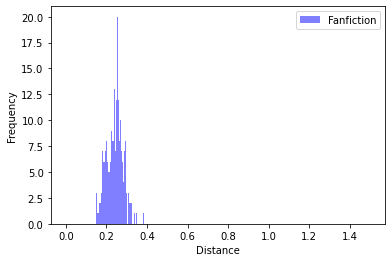

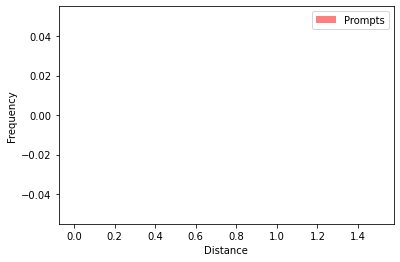

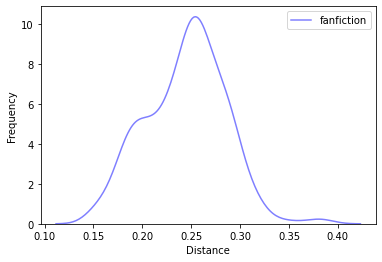

In [62]:
real_dis , prompts_dis = run_experiment_prompt_in_real("Warcraft" , experimentpath)

In [56]:
prompts_dis

,Distance


In [122]:
promptsdis

,Distance
Write me a quick fan fiction about warcraft on the aftermath of the 1.csv-Signature.csv,0.307722
Write me a warcraft fan fiction about Arthas's childhood.csv-Signature.csv,0.289222
Write me a warcraft fan fiction about the tales of the sword of frostm.csv-Signature.csv,0.291461
Write me a warcraft fan fiction about Thrall's fight against the Human.csv-Signature.csv,0.294832


In [123]:
find_best_threshold(nonpromptsdis["Distance"], promptsdis["Distance"])

Within the range [0.1408, 0.3077], there are 4 prompts and 341 reals, with a frequency of 0.0116 and a recall of 1.0000


(0.3077222640646266,
 0.022922636103151862,
 'Within the range [0.1408, 0.3077], there are 4 prompts and 341 reals, with a frequency of 0.0116 and a recall of 1.0000')

In [137]:
find_best_threshold_all(nonpromptsdis["Distance"], promptsdis["Distance"])

,best_threshold,best_f1,frequency,recall
0,0.307722,0.022923,0.011594,1.0
